In [1]:
import nltk
import numpy as np 
import pandas as pd 
import tensorflow as tf
from bs4 import BeautifulSoup
nltk.download('stopwords')
nltk.download('wordnet')

I0000 00:00:1785423424.316030   41009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785423424.347030   41009 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785423425.116788   41009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rishabh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rishabh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Loading the dataset 

In [2]:
data = pd.read_csv("../dataset/IMDB Dataset.csv")

In [3]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### TEXT Preprocessing 

In [4]:
from nltk.tokenize import word_tokenize 
import string 
from nltk.stem import WordNetLemmatizer, PorterStemmer

In [5]:
punctuations = string.punctuation

# Keep negation words out of the stopword list — dropping "not" makes
# "not worth it" and "worth it" collapse to the same tokens after cleaning.
NEGATION_WORDS = {
    "not", "no", "never", "nor", "neither", "nobody", "nothing", "nowhere",
    "cant", "cannot", "wont", "dont", "doesnt", "didnt",
    "isnt", "wasnt", "werent", "havent", "hasnt", "hadnt",
    "shouldnt", "wouldnt", "couldnt", "mightnt", "mustnt"
}
stopwords = [w for w in nltk.corpus.stopwords.words('english') if w not in NEGATION_WORDS]
lm = WordNetLemmatizer()

In [6]:
text =data['review'][1]

In [7]:
BeautifulSoup(text,"html.parser").get_text()

'A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well done.'

In [8]:
nltk.download('punkt_tab') ### required for tokenization 

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/rishabh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
def clean_text(text):
    only_text = BeautifulSoup(text, "html.parser").get_text() ## removed the html tags 
    text = "".join([char.lower() for char in only_text if char not in punctuations]) ## lower the text and remove punctuations 
    tokens = word_tokenize(text)
    final_text= " ".join([lm.lemmatize(token) for token in tokens if token not in stopwords ]) ## stopword remove and lemmatization 
    return final_text



In [10]:
clean_text("worth it ")

'worth'

In [11]:
clean_text(text)

'wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen not got polari voice pat truly see seamless editing guided reference williams diary entry not well worth watching terrificly written performed piece masterful production one great master comedy life realism really come home little thing fantasy guard rather use traditional dream technique remains solid disappears play knowledge sens particularly scene concerning orton halliwell set particularly flat halliwells mural decorating every surface terribly well done'

In [12]:
X= data['review'].apply(lambda x : clean_text(x))

In [13]:
X


0        one reviewer mentioned watching 1 oz episode y...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    no one expects star trek movie high art fan ex...
Name: review, Length: 50000, dtype: object

In [14]:
Y = data['sentiment'].apply(lambda x :1 if x =='positive' else 0)

In [15]:
Y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [16]:
## split data into train (70%), validation (15%), and test (15%) sets
## validation is used for early stopping / model selection; test is only
## touched once, at the very end, for the final reported metrics
from sklearn.model_selection import train_test_split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [17]:
X_train.shape


(35000,)

In [18]:
Y_train = np.array(Y_train, dtype=np.int32)
Y_val = np.array(Y_val, dtype=np.int32)
Y_test = np.array(Y_test, dtype=np.int32)

### Text Vectorization 

In [19]:
from tensorflow.keras.layers import TextVectorization


In [20]:
vocab_size= 20000
max_length=200

vectorize_layer = TextVectorization(
    max_tokens = vocab_size, 
    output_mode = 'int',
    output_sequence_length= max_length
)

I0000 00:00:1785423465.750855   41009 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21878 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [21]:
## Build vocabulary 

vectorize_layer.adapt(np.array(X_train))

In [22]:
vocab = np.array(vectorize_layer.get_vocabulary())
vocab[:50]

array(['', '[UNK]', 'movie', 'film', 'not', 'one', 'like', 'time', 'good',
       'character', 'get', 'story', 'would', 'even', 'no', 'make', 'see',
       'really', 'scene', 'much', 'well', 'people', 'bad', 'great',
       'also', 'show', 'first', 'dont', 'way', 'thing', 'could', 'made',
       'think', 'go', 'life', 'know', 'watch', 'seen', 'love', 'many',
       'actor', 'plot', 'say', 'two', 'never', 'look', 'end', 'acting',
       'little', 'best'], dtype='<U20')

In [23]:
vocab.shape

(20000,)

In [24]:
vectorize_training_set = vectorize_layer(X_train)

W0000 00:00:1785423467.127657   41629 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.128693   41620 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.129723   41626 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.131248   41622 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.133070   41627 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.134380   41625 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.135552   41624 gpu_kernel_to_blob_pass.cc:190] Failed to co

In [25]:
X_train.shape

(35000,)

In [26]:
vectorize_training_set.shape

TensorShape([35000, 200])

In [27]:
vectorize_training_set

<tf.Tensor: shape=(35000, 200), dtype=int64, numpy=
array([[   19,    38,   876, ...,     0,     0,     0],
       [    8, 10567,     6, ...,     0,     0,     0],
       [    4,  1235,   107, ...,     0,     0,     0],
       ...,
       [  732,     5,   288, ...,     0,     0,     0],
       [  242,    90,   564, ...,     0,     0,     0],
       [  432,     2,   179, ...,     0,     0,     0]],
      shape=(35000, 200))>

In [28]:
X_train.to_list()[2]

'not finding right word everybodys problem vaudevilletype urban comedy dont know say dont know say embark potentially humiliating enterprise prearranged speed dating unfortunately come across cardboard character rather real people story follows conventional threeact structure getting know sizable cast sorry single life actual dating circuit final stretch romantic fallout showcasing newfound couple folly predictable id say narrative shoppen failure comedy time goofy really funny thumb kathrin von steinburg stand soap opera crowd aloof independently wealthy miriam great makeup verena weißert heavy eye shadow meet skintone lip gloss creating brooding bohemian yet girlish effect thumb also stefan zinner bavarian love machine tanja schleiff hot nutritionist bypass communication challenge way timeless body language copulation'

In [29]:
vectorize_training_set[2,:]

<tf.Tensor: shape=(200,), dtype=int64, numpy=
array([    4,  1235,   107,   252,  7374,   194,     1,  2379,   104,
          27,    35,    42,    27,    35,    42,  9000,  3686,  8210,
        4083,     1,  1943,  3742,   406,    55,   487,  2980,     9,
         157,    65,    21,    11,   953,  3830,     1,  2141,   282,
          35, 18110,    87,   669,   567,    34,   661,  3742,  7775,
         362,  2382,   631, 14822, 11461, 10390,   250, 11590,   611,
         371,    42,  1141,     1,  1673,   104,     7,  2557,    17,
          77,  2749,     1,  2689,     1,   458,  1652,  1177,  1636,
        9702, 12424,  2564, 10820,    23,  1257,     1,     1,  1369,
         247,  1616,   386,     1,  2916,  9831,  1618,  5434, 12891,
         159,     1,   143,  2749,    24,  6756,     1,     1,    38,
        1170,     1,     1,   800,     1, 18658,  5483,  2094,    28,
        3549,   426,   911,     1,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,   

In [30]:
np.where(vocab=='cockchasing')

(array([], dtype=int64),)

In [31]:
X_train_tf = tf.constant(X_train, dtype=tf.string)
X_val_tf = tf.constant(X_val, dtype=tf.string)
X_test_tf = tf.constant(X_test, dtype=tf.string)

### Building Embedding Layer

In [32]:
from tensorflow.keras.layers import Embedding
embed = Embedding(
    input_dim=len(vocab),
    output_dim=100
)

In [33]:
embed(vectorize_training_set[2,:])

W0000 00:00:1785423467.633194   41640 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.634230   41637 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.635890   41646 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.637168   41650 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.638931   41645 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.640258   41649 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423467.642037   41638 gpu_kernel_to_blob_pass.cc:190] Failed to co

<tf.Tensor: shape=(200, 100), dtype=float32, numpy=
array([[ 0.01299402,  0.01960745,  0.03261727, ...,  0.0111302 ,
        -0.03233077, -0.00580653],
       [-0.01327724,  0.0181087 ,  0.02922523, ...,  0.04313446,
         0.01826293,  0.03846886],
       [ 0.01274126,  0.01696576,  0.03456202, ...,  0.04762464,
         0.0311571 ,  0.03866079],
       ...,
       [-0.04022421, -0.02033664, -0.040716  , ...,  0.00890704,
        -0.00103568,  0.02442951],
       [-0.04022421, -0.02033664, -0.040716  , ...,  0.00890704,
        -0.00103568,  0.02442951],
       [-0.04022421, -0.02033664, -0.040716  , ...,  0.00890704,
        -0.00103568,  0.02442951]], shape=(200, 100), dtype=float32)>

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import LSTM, Dense,Dropout

model = Sequential()
model.add(tf.keras.Input(shape=(),dtype=tf.string))

model.add(vectorize_layer)
model.add(Embedding(input_dim=vocab_size,output_dim= 100,mask_zero=True))
model.add(LSTM(100))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.summary()


W0000 00:00:1785423467.900554   41009 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,086,929 (7.96 MB)

 Trainable params: 2,086,929 (7.96 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

### Model Training 

In [36]:
from tensorflow.keras.callbacks import EarlyStopping



early_stop= EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True

)

history = model.fit(
    X_train_tf, Y_train,
    validation_data=(X_val_tf, Y_val),
    batch_size=32,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


W0000 00:00:1785423468.702279   41605 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423468.758614   41822 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423468.759646   41815 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423468.760680   41817 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423468.761717   41814 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423468.763351   41827 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423468.764763   41813 gpu_kernel_to_blob_pass.cc:190] Failed to co

I0000 00:00:1785423468.935198   41602 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1785423469.002699   41602 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.034311   41602 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.068859   41602 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


W0000 00:00:1785423469.214709   41868 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.215749   41872 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.216788   41873 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.217819   41867 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.219430   41869 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.221282   41875 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.222886   41871 gpu_kernel_to_blob_pass.cc:190] Failed to co

W0000 00:00:1785423469.500423   41602 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.530895   41602 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.568352   41602 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.610962   41602 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.656667   41605 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1785423469.699033   41605 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


...

1070/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0355

1077/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0355

1085/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0355

1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0355

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9883 - loss: 0.0359 - val_accuracy: 0.8556 - val_loss: 0.6733


In [37]:
model.save("../models/sentiment_classifier_1.keras")

### Accuracy Visualisation 

In [38]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

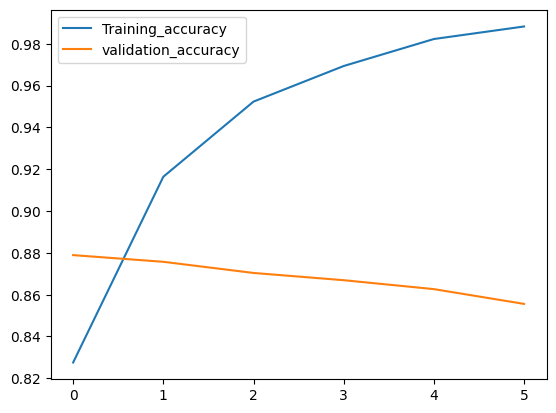

In [39]:
import matplotlib.pyplot as plt 
plt.plot(history.history['accuracy'], label ="Training_accuracy")
plt.plot(history.history['val_accuracy'], label ="validation_accuracy")
plt.legend()
plt.show()

In [40]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,260,789 (23.88 MB)

 Trainable params: 2,086,929 (7.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,173,860 (15.92 MB)

### Testing Model on random test 

In [41]:
print(model.input_shape)
print(model.inputs)

(None,)
[<KerasTensor shape=(None,), dtype=string, sparse=False, ragged=False, name=keras_tensor>]


In [42]:


sample = tf.constant(
    ["movie was good , but i didnt like the ending  "],
    dtype=tf.string
)


prediction = model.predict(sample)
if prediction>0.5 :
    print("Positive Sentiment,""\nscore : ",prediction[0][0])
else :
    print("Negative Sentiment," "\nscore : ",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


Negative Sentiment,
score :  0.44206437


In [43]:


sample_2 = tf.constant(
    ["movie was good  "],
    dtype=tf.string
)


prediction = model.predict(sample_2)
if prediction>0.5 :
    print("Positive Sentiment,""\nscore : ",prediction[0][0])
else :
    print("Negative Sentiment," "\nscore : ",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


Positive Sentiment,
score :  0.53456306


In [44]:
print(vectorize_layer(["not worth it"]).numpy()[0][:5])
print(vectorize_layer(["worth it"]).numpy()[0][:5])
print("not" in vocab)  # should now be True — negation words are no longer stripped as stopwords

[  4 187   1   0   0]
[187   1   0   0   0]
True


In [45]:
## "not" now survives cleaning and gets its own vocab id, so "not worth it" and
## "worth it" are no longer identical token sequences going into the model.

In [46]:
## Model Evaluation 

 ## precision , recall, F1 score ,confusion matrix 

In [47]:
type(X_train)

pandas.core.series.Series

In [48]:
y_pred = model.predict(X_test_tf)


  1/235 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step

 19/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

 36/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 54/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 72/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...

179/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

196/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

214/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

232/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [49]:
y_pred_binary = np.where(y_pred>0.5,1,0)
y_pred_binary

array([[0],
       [0],
       [0],
       ...,
       [0],
       [1],
       [0]], shape=(7500, 1))

In [50]:
y_pred_binary.shape

(7500, 1)

In [51]:
y_true = np.array(Y_test)
y_pred_flat = y_pred_binary.flatten()

In [52]:
y_true


array([0, 0, 0, ..., 0, 1, 0], shape=(7500,), dtype=int32)

In [53]:
y_pred_flat

array([0, 0, 0, ..., 0, 1, 0], shape=(7500,))

In [54]:
y_true.shape



(7500,)

In [55]:
y_pred_flat.shape

(7500,)

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      3722
           1       0.87      0.89      0.88      3778

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500



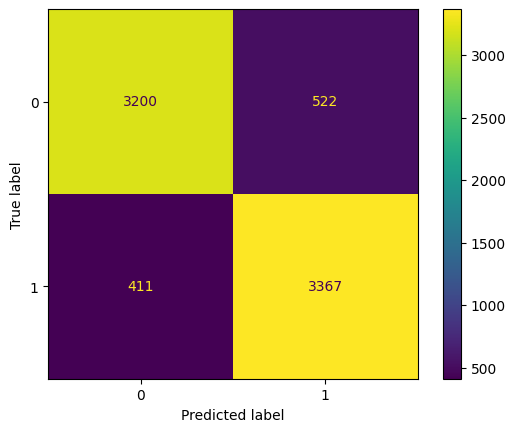

In [56]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred_flat))
disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred_flat))
disp.plot()